In [5]:
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
df = pd.read_csv("social_data.csv")



In [10]:
df['engagement'] = df['likes'] + df['comments'] + df['shares']


In [11]:
print(df.head())


  post_id   post_date post_time   platform post_type  likes  comments  shares  \
0   IG052  2024-10-03     21:00  Instagram      Reel    354        26       7   
1   IG080  2024-10-04     17:00  Instagram  Carousel    240         9      28   
2   IG090  2024-10-06     19:00  Instagram      Post    241        36       7   
3   IG027  2024-10-08     20:00  Instagram      Post    129        25      15   
4   IG067  2024-10-11     18:00  Instagram      Reel    465        67      40   

   reach  caption_length  hashtags_count  engagement  
0   5222             117              12         387  
1   1737             199              28         277  
2   2068             176              16         284  
3   1561             286              19         169  
4   2659              56               5         572  


In [12]:
post_type_engagement = df.groupby('post_type')['engagement'].mean()
print("\nEngagement by Post Type:\n", post_type_engagement)




Engagement by Post Type:
 post_type
Carousel    269.851852
Post        226.212121
Reel        412.125000
Name: engagement, dtype: float64


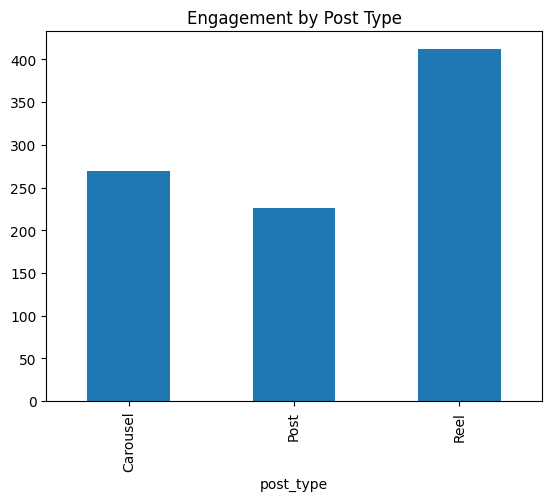

In [13]:
post_type_engagement.plot(kind='bar')
plt.title("Engagement by Post Type")
plt.show()

# Reels generate the highest engagement compared to posts and carousels


Best Time:
 post_time
20:00    283.357143
17:00    287.083333
08:00    288.461538
21:00    302.642857
19:00    320.909091
18:00    323.500000
09:00    328.000000
12:00    347.000000
11:00    359.375000
Name: engagement, dtype: float64


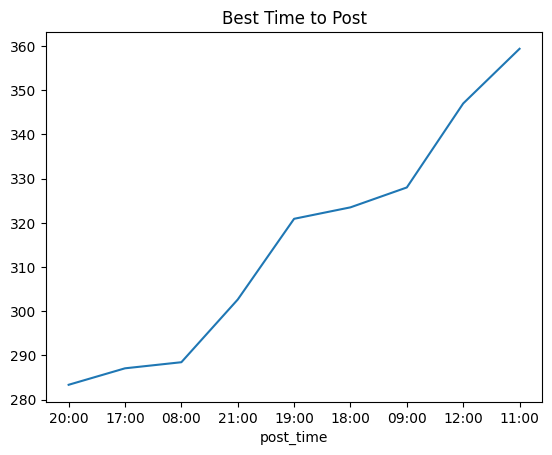

In [14]:
time_engagement = df.groupby('post_time')['engagement'].mean().sort_values()

print("\nBest Time:\n", time_engagement)

time_engagement.plot(kind='line')
plt.title("Best Time to Post")
plt.show()

# Engagement peaks around evening hours (18:00–21:00)



Caption Impact:
 caption_category
Long      253.102564
Medium    350.245902
Name: engagement, dtype: float64


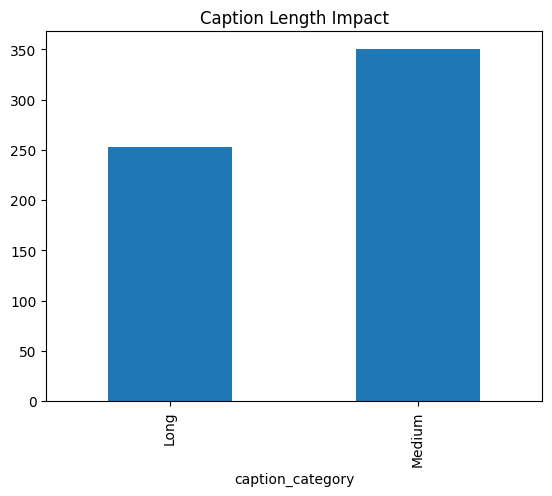

In [15]:
def caption_type(x):
    if x < 50:
        return "Short"
    elif x <= 150:
        return "Medium"
    else:
        return "Long"

df['caption_category'] = df['caption_length'].apply(caption_type)

caption_analysis = df.groupby('caption_category')['engagement'].mean()

print("\nCaption Impact:\n", caption_analysis)

caption_analysis.plot(kind='bar')
plt.title("Caption Length Impact")
plt.show()


# Medium-length captions perform better than very short or long captions